In [19]:
# Importing Libraries
import seaborn as sns
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [10]:
df_US= df[df['job_country']=='United States']

In [11]:
df_skills=df_US.explode('job_skills')

df_skills[['job_title_short', 'job_skills']]

,job_title_short,job_skills
0,Senior Data Engineer,NaN
3,Data Engineer,python
3,Data Engineer,c++
3,Data Engineer,java
3,Data Engineer,matlab
...,...,...
785692,Data Scientist,r
785703,Data Analyst,NaN
785705,Data Analyst,sql
785705,Data Analyst,python


In [12]:
df_skills_count= df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count= df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending= False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [21]:
top_jobs = df_job_title_count.head(3)['job_title_short'].tolist()
job_titles = sorted(top_jobs)
job_titles


['Data Analyst', 'Data Engineer', 'Data Scientist']

In [20]:
df_job_title_count = (
    df_US['job_title_short']
    .value_counts()
    .reset_index()
)
df_job_title_count.columns = ['job_title_short', 'job_total']
df_job_title_count = df_job_title_count.sort_values(by='job_total', ascending=False)

df_job_title_count.head()


,job_title_short,job_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791


In [15]:
df_skills_perc= pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')

df_skills_perc['skill_percentage']= 100*(df_skills_perc['skill_count']/ df_skills_perc['job_total'])
df_skills_perc

,job_skills,job_title_short,skill_count,job_total,skill_percentage
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


C:\Users\PC\AppData\Local\Temp\ipykernel_10028\2981790582.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=axes[i, 0], palette='dark:b_r')
C:\Users\PC\AppData\Local\Temp\ipykernel_10028\2981790582.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=axes[i, 0], palette='dark:b_r')
C:\Users\PC\AppData\Local\Temp\ipykernel_10028\2981790582.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='skill_percentage', y='job_

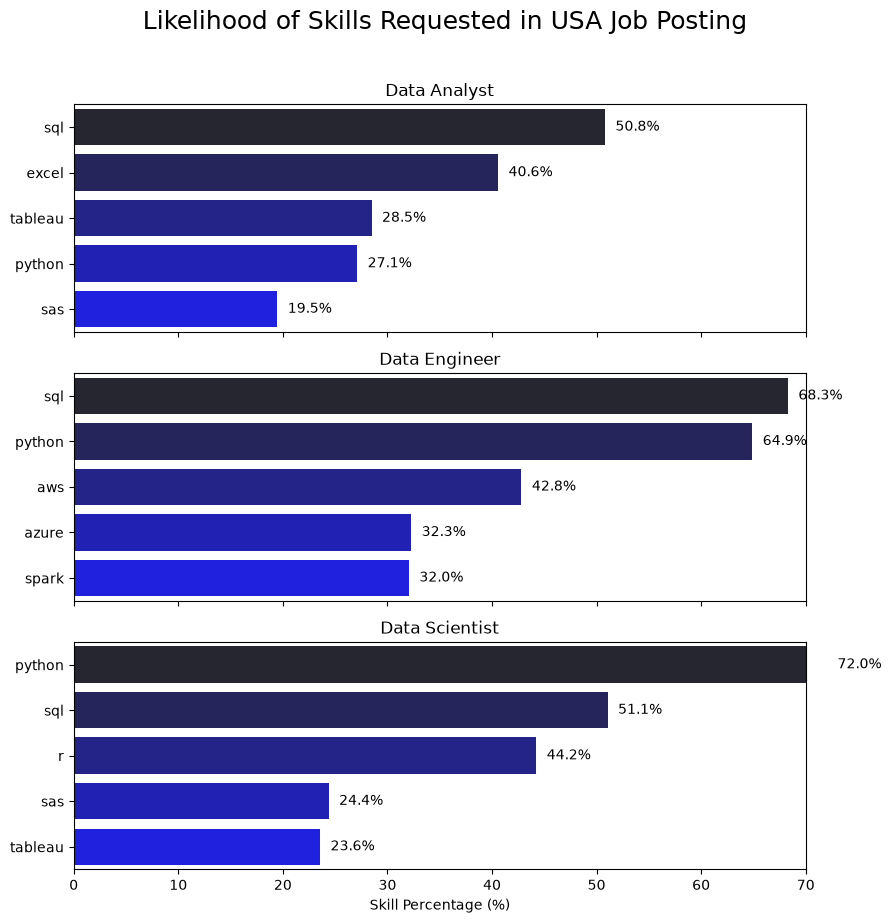

In [54]:
fig, axes = plt.subplots(len(job_titles), 1, figsize=(9, 3 * len(job_titles)), squeeze=False)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    df_plot = df_plot.sort_values(by='skill_percentage', ascending=True)
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=axes[i, 0], palette='dark:b_r')
    
    axes[i, 0].set_title(job_title)
    axes[i, 0].invert_yaxis()
    axes[i, 0].set_ylabel('')
    axes[i, 0].set_xlim(0, 70)

    # Only bottom graph gets x-axis label
    if i == len(job_titles) - 1:
        axes[i, 0].set_xlabel('Skill Percentage (%)')
    else:
        axes[i, 0].set_xlabel('')
        axes[i, 0].tick_params(labelbottom=False)  # hide tick labels too

    # annotate bars
    for n, v in enumerate(df_plot['skill_percentage']):
        axes[i, 0].text(v + 1, n, f"{v:.1f}%", va='center')

fig.suptitle('Likelihood of Skills Requested in USA Job Posting', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()


